In [1]:
import numpy as mp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('New_India_Healthcare_Data_2026.csv')

In [3]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'State', 'Socioeconomic_Status',
       'Occupation', 'Visit_Date', 'Symptoms', 'Primary_Diagnosis',
       'Fasting_Blood_Glucose__mg_dl', 'Glycemic_Status', 'HbA1c_mmol_mol',
       'Total_Cholesterol_mg_dL', 'Treatment_Type', 'Treatment_Outcome',
       'Imaging Type', 'Imaging Findings', 'Hospital Type',
       'Insurance Covered', 'BMI (kg meter square)', 'BMI Status', 'Age Group',
       'Visit Year', 'Visit Month', 'Symptom Blurred Vision',
       'Symptom Chest Pain', 'Symptom Cough', 'Symptom Fatigue',
       'Symptom Fever', 'Symptom Frequent Urination', 'Symptom Headache',
       'Symptom High Bp', 'Symptom High Fever', 'Symptom Increased Thirst',
       'Symptom Joint Pain', 'Symptom Night Sweats',
       'Symptom Shortness Of Breath', 'Symptom Swelling In Legs',
       'Symptom Weight Loss'],
      dtype='object')

HbA1c_mmol_mol
31.2    21871
38.8    17863
47.5    20720
63.9    23044
85.5    12183
85.8     4319
Name: count, dtype: int64


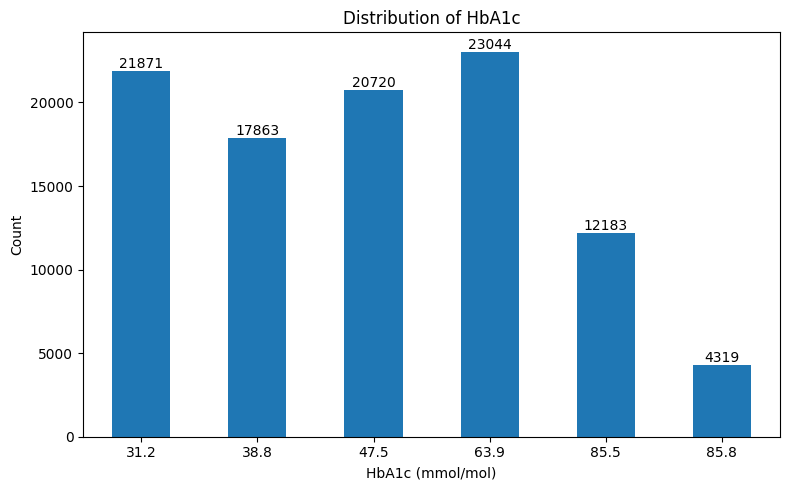

In [4]:
hba1c_count = df["HbA1c_mmol_mol"].value_counts().sort_index()
print(hba1c_count)
ax = hba1c_count.plot(kind="bar", figsize=(8, 5))
for container in ax.containers:
 for container in ax.containers:
    ax.bar_label(container)
plt.title("Distribution of HbA1c")
plt.xlabel("HbA1c (mmol/mol)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Visit Year
2024    29966
2025    49822
2026    20212
Name: count, dtype: int64


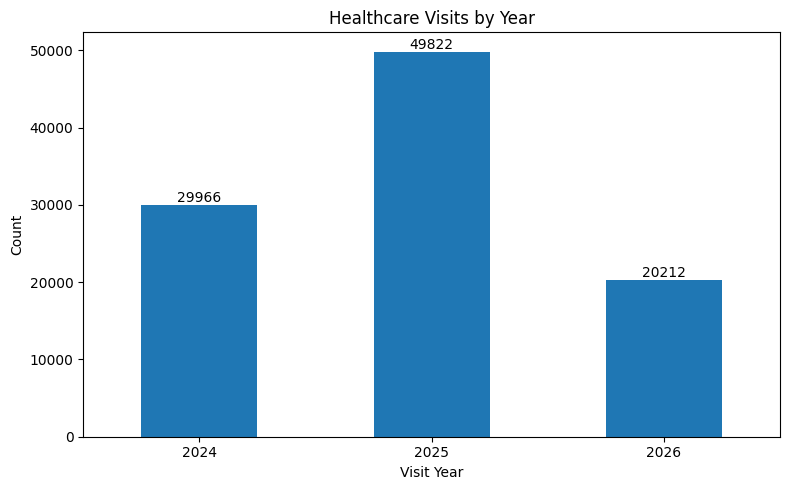

In [5]:
year_count = df['Visit Year'].value_counts().sort_index()
print(year_count)
bx = year_count.plot(kind='bar', figsize=(8, 5))
for container in bx.containers:
    bx.bar_label(container)
plt.title('Healthcare Visits by Year')
plt.xlabel('Visit Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Visit Month
1     8479
2     7650
3     8434
4     8242
5     8594
6     8212
7     8540
8     8547
9     8136
10    8613
11    8117
12    8436
Name: count, dtype: int64


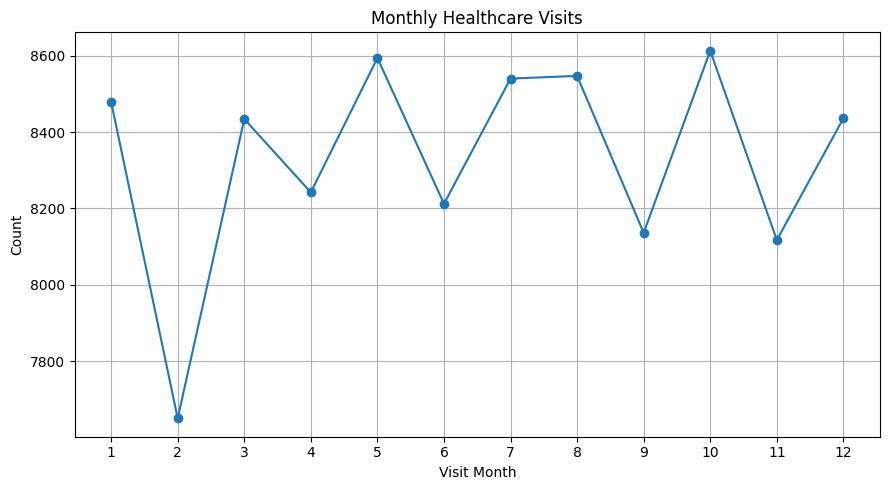

In [6]:
month_count = df['Visit Month'].value_counts().sort_index()
print(month_count)
cx = month_count.plot(kind='line', marker='o', figsize=(9, 5))
for container in cx.containers:
    cx.bar_label(container)
plt.title('Monthly Healthcare Visits')
plt.xlabel('Visit Month')
plt.ylabel('Count')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
df.head()

,Patient_ID,Age,Gender,State,Socioeconomic_Status,Occupation,Visit_Date,Symptoms,Primary_Diagnosis,Fasting_Blood_Glucose__mg_dl,...,Symptom Frequent Urination,Symptom Headache,Symptom High Bp,Symptom High Fever,Symptom Increased Thirst,Symptom Joint Pain,Symptom Night Sweats,Symptom Shortness Of Breath,Symptom Swelling In Legs,Symptom Weight Loss
0,21D74F65-E20,53,Female,Andhra Pradesh,Low,Agricultural Consultant,18-09-2025,"Fever, Fatigue, Increased Thirst",Dengue,100.9,...,0,0,0,0,1,0,0,0,0,0
1,0BCF80B5-312,36,Male,Puducherry,Low,Haematologist,14-11-2024,"Swelling In Legs, High Bp",Malaria,121.3,...,0,0,1,0,0,0,0,0,1,0
2,5EF60C7B-8E6,28,Male,Maharashtra,Low,Financial Risk Analyst,20-02-2026,"Fever, Fatigue, Increased Thirst",Hypertension,74.7,...,0,0,0,0,1,0,0,0,0,0
3,93959ACB-8BA,34,Female,Karnataka,Low,Clinical Research Associate,04-11-2025,"Fever, Fatigue, Increased Thirst",Cardiovascular Disease,102.7,...,0,0,0,0,1,0,0,0,0,0
4,B11DB540-128,48,Female,Puducherry,High,Agricultural Consultant,15-08-2025,"Frequent Urination, Blurred Vision",Hypertension,70.0,...,1,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(100000, 39)

In [9]:
df.isnull().sum()

Patient_ID                      0
Age                             0
Gender                          0
State                           0
Socioeconomic_Status            0
Occupation                      0
Visit_Date                      0
Symptoms                        0
Primary_Diagnosis               0
Fasting_Blood_Glucose__mg_dl    0
Glycemic_Status                 0
HbA1c_mmol_mol                  0
Total_Cholesterol_mg_dL         0
Treatment_Type                  0
Treatment_Outcome               0
Imaging Type                    0
Imaging Findings                0
Hospital Type                   0
Insurance Covered               0
BMI (kg meter square)           0
BMI Status                      0
Age Group                       0
Visit Year                      0
Visit Month                     0
Symptom Blurred Vision          0
Symptom Chest Pain              0
Symptom Cough                   0
Symptom Fatigue                 0
Symptom Fever                   0
Symptom Freque

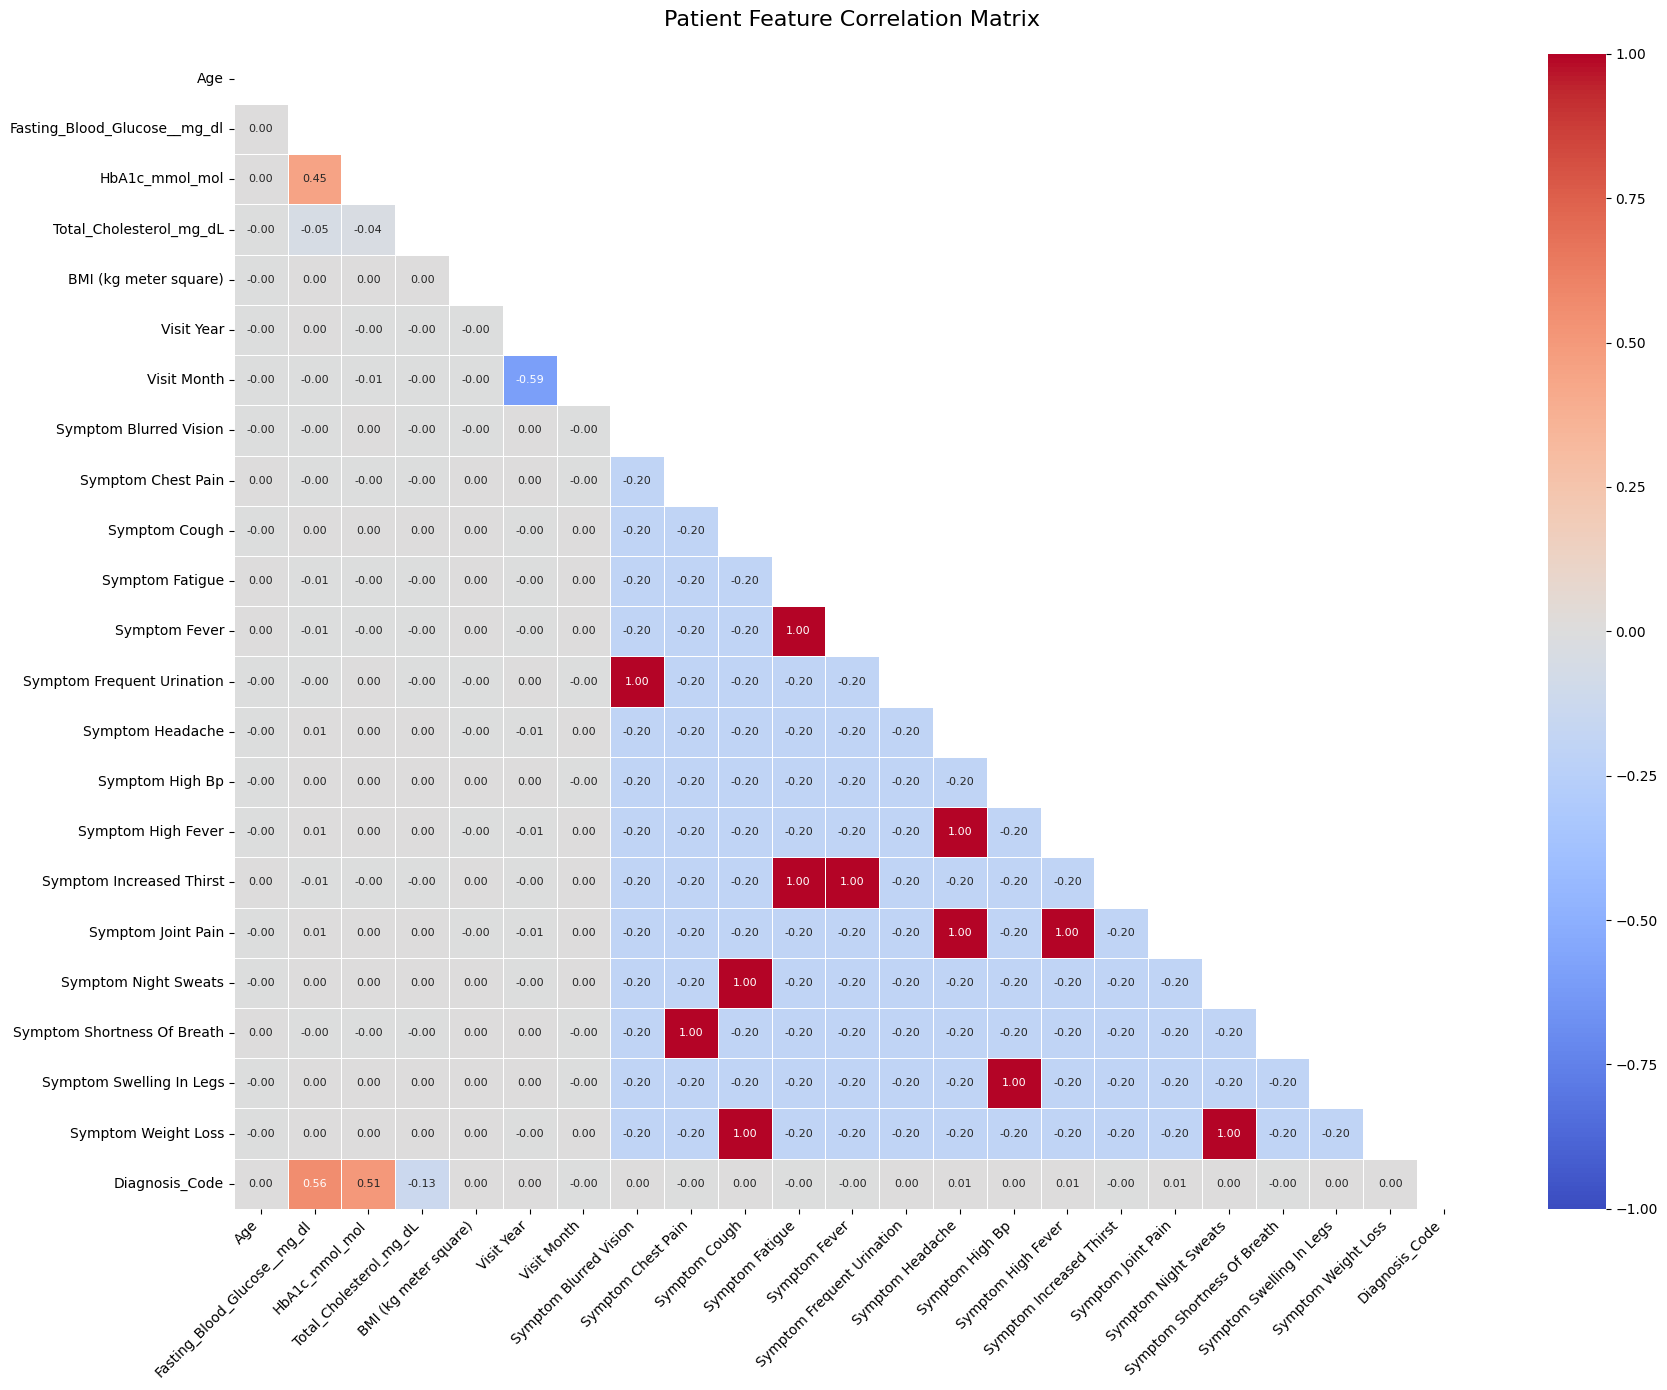

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_corr = df.copy()

if 'Primary_Diagnosis' in df_corr.columns:
    df_corr['Diagnosis_Code'] = df_corr['Primary_Diagnosis'].astype('category').cat.codes

numerical_cols = df_corr.select_dtypes(include=['int64', 'float64', 'int8', 'int16', 'int32']).columns
correlation_matrix = df_corr[numerical_cols].corr()

plt.figure(figsize=(18, 14)) 

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))


sns.heatmap(
    correlation_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f",              
    cmap='coolwarm', 
    vmin=-1, vmax=1,         
    linewidths=0.5,          
    annot_kws={"size": 8}   
)


plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Patient Feature Correlation Matrix", fontsize=16, pad=20)

plt.tight_layout() 
plt.show()

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df_corr[['HbA1c_mmol_mol']] 
y = df_corr['Fasting_Blood_Glucose__mg_dl']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Linear Regression Results:
Coefficient (Slope): 1.10
Intercept: 70.79
Mean Squared Error (MSE): 1629.80
R-squared: 0.20


In [32]:
from sklearn.preprocessing import LabelEncoder

ses_map = {'Low': 0, 'Middle': 1, 'High': 2}
glycemic_map = {'Normal': 0, 'Prediabetes': 1, 'Hyperglycemia': 2}
bmi_map = {'Underweight': 0, 'Healthy': 1, 'Overweight': 2, 'Obesity': 3}

df['Socioeconomic_Status_Encoded'] = df['Socioeconomic_Status'].map(ses_map)
df['Glycemic_Status_Encoded'] = df['Glycemic_Status'].map(glycemic_map)
df['BMI_Status_Encoded'] = df['BMI Status'].map(bmi_map)


le = LabelEncoder()
df['Insurance_Encoded'] = le.fit_transform(df['Insurance Covered']) 



nominal_columns = [
    'Gender',
    'State', 
    'Hospital Type',       
    'Treatment_Type', 
    'Primary_Diagnosis',
    'Imaging Type',
    'Treatment_Outcome',   
    'Age Group'
]


df_encoded = pd.get_dummies(df, columns=nominal_columns, drop_first=True)


bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)


df_final = df_encoded.drop(columns=[
    'Socioeconomic_Status', 
    'Glycemic_Status', 
    'BMI Status', 
    'Insurance Covered'
])

In [33]:
df_final

,Patient_ID,Age,Occupation,Visit_Date,Symptoms,Fasting_Blood_Glucose__mg_dl,HbA1c_mmol_mol,Total_Cholesterol_mg_dL,Imaging Findings,BMI (kg meter square),...,Imaging Type_MRI,Imaging Type_No Imaging,Imaging Type_Ultrasound,Imaging Type_X-Ray,Treatment_Outcome_Recovered,Treatment_Outcome_Referred,Treatment_Outcome_Stable,Treatment_Outcome_Worsened,Age Group_36-60,Age Group_60+
0,21D74F65-E20,53,Agricultural Consultant,18-09-2025,"Fever, Fatigue, Increased Thirst",100.9,47.5,233,Evidence Of Pleural Effusion,23,...,0,0,1,0,0,0,0,0,1,0
1,0BCF80B5-312,36,Haematologist,14-11-2024,"Swelling In Legs, High Bp",121.3,31.2,231,No Imaging Performed,27,...,0,1,0,0,0,1,0,0,1,0
2,5EF60C7B-8E6,28,Financial Risk Analyst,20-02-2026,"Fever, Fatigue, Increased Thirst",74.7,85.5,240,No Imaging Performed,29,...,0,1,0,0,0,0,0,0,0,0
3,93959ACB-8BA,34,Clinical Research Associate,04-11-2025,"Fever, Fatigue, Increased Thirst",102.7,38.8,240,No Significant Abnormality Detected,26,...,0,0,0,0,0,1,0,0,0,0
4,B11DB540-128,48,Agricultural Consultant,15-08-2025,"Frequent Urination, Blurred Vision",70.0,47.5,240,No Significant Abnormality Detected,33,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,E5E77187-DFB,38,"Radiographer, Therapeutic",04-02-2025,"Fever, Fatigue, Increased Thirst",142.5,85.5,214,No Significant Abnormality Detected,33,...,0,0,0,1,0,1,0,0,1,0
99996,89D76B82-945,32,"Geologist, Engineering",29-09-2025,"Cough, Weight Loss, Night Sweats",132.5,31.2,217,Mild Cardiomegaly Observed,33,...,0,0,0,1,1,0,0,0,0,0
99997,2E0BC707-F6E,36,Sports Development Officer,04-09-2024,"Chest Pain, Shortness Of Breath",97.7,47.5,240,Normal Study,22,...,0,0,1,0,1,0,0,0,1,0
99998,5F6855D2-DFF,32,Theatre Director,08-02-2025,"Headache, Joint Pain, High Fever",140.6,47.5,234,No Imaging Performed,21,...,0,1,0,0,1,0,0,0,0,0


In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

continuous_cols = [
    'Age', 
    'Fasting_Blood_Glucose__mg_dl', 
    'HbA1c_mmol_mol', 
    'Total_Cholesterol_mg_dL',
    'BMI (kg meter square)'
]

scaler = StandardScaler()


df_final[continuous_cols] = scaler.fit_transform(df_final[continuous_cols])

In [35]:
df_final

,Patient_ID,Age,Occupation,Visit_Date,Symptoms,Fasting_Blood_Glucose__mg_dl,HbA1c_mmol_mol,Total_Cholesterol_mg_dL,Imaging Findings,BMI (kg meter square),...,Imaging Type_MRI,Imaging Type_No Imaging,Imaging Type_Ultrasound,Imaging Type_X-Ray,Treatment_Outcome_Recovered,Treatment_Outcome_Referred,Treatment_Outcome_Stable,Treatment_Outcome_Worsened,Age Group_36-60,Age Group_60+
0,21D74F65-E20,0.441873,Agricultural Consultant,18-09-2025,"Fever, Fatigue, Increased Thirst",-0.610669,-0.264851,0.847229,Evidence Of Pleural Effusion,-0.301979,...,0,0,1,0,0,0,0,0,1,0
1,0BCF80B5-312,-0.750094,Haematologist,14-11-2024,"Swelling In Legs, High Bp",-0.160981,-1.138065,0.731933,No Imaging Performed,0.450902,...,0,1,0,0,0,1,0,0,1,0
2,5EF60C7B-8E6,-1.311020,Financial Risk Analyst,20-02-2026,"Fever, Fatigue, Increased Thirst",-1.188209,1.770864,1.250764,No Imaging Performed,0.827343,...,0,1,0,0,0,0,0,0,0,0
3,93959ACB-8BA,-0.890326,Clinical Research Associate,04-11-2025,"Fever, Fatigue, Increased Thirst",-0.570990,-0.730922,1.250764,No Significant Abnormality Detected,0.262682,...,0,0,0,0,0,1,0,0,0,0
4,B11DB540-128,0.091294,Agricultural Consultant,15-08-2025,"Frequent Urination, Blurred Vision",-1.291814,-0.264851,1.250764,No Significant Abnormality Detected,1.580223,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,E5E77187-DFB,-0.609863,"Radiographer, Therapeutic",04-02-2025,"Fever, Fatigue, Increased Thirst",0.306342,1.770864,-0.248080,No Significant Abnormality Detected,1.580223,...,0,0,0,1,0,1,0,0,1,0
99996,89D76B82-945,-1.030557,"Geologist, Engineering",29-09-2025,"Cough, Weight Loss, Night Sweats",0.085907,-1.138065,-0.075136,Mild Cardiomegaly Observed,1.580223,...,0,0,0,1,1,0,0,0,0,0
99997,2E0BC707-F6E,-0.750094,Sports Development Officer,04-09-2024,"Chest Pain, Shortness Of Breath",-0.681208,-0.264851,1.250764,Normal Study,-0.490199,...,0,0,1,0,1,0,0,0,1,0
99998,5F6855D2-DFF,-1.030557,Theatre Director,08-02-2025,"Headache, Joint Pain, High Fever",0.264460,-0.264851,0.904877,No Imaging Performed,-0.678419,...,0,1,0,0,1,0,0,0,0,0


In [38]:
import pandas as pd
from scipy.stats import pearsonr

df_cleaned = df_final.dropna()

target_var = 'Fasting_Blood_Glucose__mg_dl'

selected_features = [
    'Age', 
    'HbA1c_mmol_mol', 
    'Total_Cholesterol_mg_dL',
    'BMI (kg meter square)',
    'Socioeconomic_Status_Encoded', 
    'Insurance_Encoded',
    'Gender_Male',             
    'Hospital Type_Private',   
    'Hospital Type_Government' 
]


correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned[target_var])[0]
    for feature in selected_features
}


correlation_df = pd.DataFrame(correlations.items(), columns=['Feature', 'Pearson Correlation'])
correlation_df = correlation_df.sort_values(by='Pearson Correlation', ascending=False)



In [39]:
correlation_df

,Feature,Pearson Correlation
1,HbA1c_mmol_mol,0.452031
4,Socioeconomic_Status_Encoded,0.005684
5,Insurance_Encoded,0.004768
0,Age,0.003253
3,BMI (kg meter square),0.001239
8,Hospital Type_Government,0.000572
6,Gender_Male,-0.003472
7,Hospital Type_Private,-0.004277
2,Total_Cholesterol_mg_dL,-0.047175


In [40]:
import pandas as pd
from scipy.stats import chi2_contingency

glycemic_map = {'Normal': 0, 'Prediabetes': 1, 'Hyperglycemia': 2}
df['Glycemic_Status_Encoded'] = df['Glycemic_Status'].map(glycemic_map)
df['Socioeconomic_Encoded'] = df['Socioeconomic_Status'].map({'Low': 0, 'Middle': 1, 'High': 2})
df['Hospital_Private'] = (df['Hospital Type'] == 'Private').astype(int)

target_var = 'Fasting_Blood_Glucose__mg_dl'

cat_features = [
    'Glycemic_Status_Encoded', 
    'Socioeconomic_Encoded', 
    'Hospital_Private',
    'Symptom Frequent Urination', 
    'Symptom Increased Thirst'    
]

df['target_bin'] = pd.qcut(df[target_var], q=4, labels=False, duplicates='drop')

alpha = 0.05
chi2_results = {}
selected_cat_features = []

for col in cat_features:
    contingency = pd.crosstab(df[col], df['target_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    
    if p_val < alpha:
        decision = 'Reject Null (Keep Feature)'
        selected_cat_features.append(col)
    else:
        decision = 'Accept Null (Drop Feature)'
    
    chi2_results[col] = {
        'chi2_statistic': round(chi2_stat, 4),
        'p_value': round(p_val, 4),
        'Decision': decision
    }


print("Chi-Square Feature Selection Results")
print(pd.DataFrame(chi2_results).T)


continuous_features = ['Age', 'HbA1c_mmol_mol', 'Total_Cholesterol_mg_dL']

final_features = continuous_features + selected_cat_features + [target_var]


final_df = df[final_features]

print(f"\nFinal Selected Features for Linear Regression:\n{final_df.columns.tolist()}")

Chi-Square Feature Selection Results
                           chi2_statistic p_value                    Decision
Glycemic_Status_Encoded        145295.007     0.0  Reject Null (Keep Feature)
Socioeconomic_Encoded             10.3433  0.1109  Accept Null (Drop Feature)
Hospital_Private                    4.112  0.2496  Accept Null (Drop Feature)
Symptom Frequent Urination         1.0991  0.7773  Accept Null (Drop Feature)
Symptom Increased Thirst           3.5194  0.3183  Accept Null (Drop Feature)

Final Selected Features for Linear Regression:
['Age', 'HbA1c_mmol_mol', 'Total_Cholesterol_mg_dL', 'Glycemic_Status_Encoded', 'Fasting_Blood_Glucose__mg_dl']


In [51]:
selected_columns = [

    'Age', 
    'HbA1c_mmol_mol', 
    'Total_Cholesterol_mg_dL',
    'BMI (kg meter square)',
    'Glycemic_Status_Encoded',
    'BMI_Status_Encoded',
    'Symptom Frequent Urination',
    'Symptom Increased Thirst',
    'Symptom Fatigue',
    'Symptom Blurred Vision',
    'Socioeconomic_Status_Encoded',
    'Insurance_Encoded',
    'Gender_Male',
    'Hospital Type_Government',
    'Hospital Type_Private',
    'Fasting_Blood_Glucose__mg_dl'
]

final_df = df_final[selected_columns]

In [52]:
final_df.to_csv('fairness_auditing_healthcare_data.csv', index=False)